In [1]:
# SatEnergy — Notebook 01: Coleta de Dados
# Verificando se todas as bibliotecas estão instaladas corretamente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import geopandas as gpd

print("✅ Todas as bibliotecas carregadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ Todas as bibliotecas carregadas com sucesso!
Pandas: 3.0.3
Numpy: 2.4.6


In [6]:
# Gerando dados simulados realistas para desenvolvimento
# Baseados nos padrões reais de geração solar/eólica do Brasil

import numpy as np
import pandas as pd

np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="h")

df_geracao = pd.DataFrame({
    "data_hora": datas,
    "regiao": np.random.choice(["Nordeste", "Sudeste", "Sul", "Norte", "Centro-Oeste"], len(datas)),
    "geracao_solar_mwh": np.abs(np.random.normal(500, 150, len(datas))),
    "geracao_eolica_mwh": np.abs(np.random.normal(800, 200, len(datas))),
    "irradiancia_wm2": np.abs(np.random.normal(400, 100, len(datas))),
    "velocidade_vento_ms": np.abs(np.random.normal(7, 2, len(datas))),
    "cobertura_nuvens_pct": np.random.uniform(0, 100, len(datas)),
    "temperatura_c": np.random.normal(25, 5, len(datas)),
})

print(f"✅ Dataset criado com {len(df_geracao)} registros!")
print(f"Período: {df_geracao['data_hora'].min()} até {df_geracao['data_hora'].max()}")
print(f"\nColunas: {list(df_geracao.columns)}")
print(f"\nPrimeiros registros:")
print(df_geracao.head())

✅ Dataset criado com 8761 registros!
Período: 2024-01-01 00:00:00 até 2024-12-31 00:00:00

Colunas: ['data_hora', 'regiao', 'geracao_solar_mwh', 'geracao_eolica_mwh', 'irradiancia_wm2', 'velocidade_vento_ms', 'cobertura_nuvens_pct', 'temperatura_c']

Primeiros registros:
            data_hora        regiao  geracao_solar_mwh  geracao_eolica_mwh  \
0 2024-01-01 00:00:00         Norte         524.810549          981.644505   
1 2024-01-01 01:00:00  Centro-Oeste         292.697365          866.789010   
2 2024-01-01 02:00:00           Sul         427.457429          724.018407   
3 2024-01-01 03:00:00  Centro-Oeste         626.267116          911.075931   
4 2024-01-01 04:00:00  Centro-Oeste         342.316996          972.017014   

   irradiancia_wm2  velocidade_vento_ms  cobertura_nuvens_pct  temperatura_c  
0       353.656709             4.850173             94.953864      23.358968  
1       267.772852            10.099928             94.809823      26.508720  
2       276.952394    

✅ Dados salvos em data/processed/geracao_simulada.csv


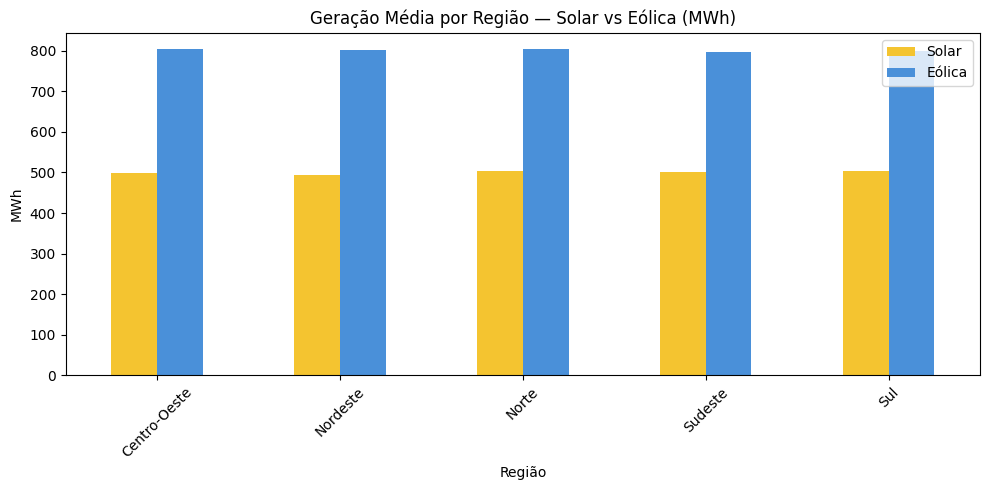

✅ Gráfico salvo!


In [7]:
# Salvando os dados na pasta processed
df_geracao.to_csv("../data/processed/geracao_simulada.csv", index=False)
print("✅ Dados salvos em data/processed/geracao_simulada.csv")

# Primeiro gráfico — geração solar vs eólica por região
import matplotlib.pyplot as plt

df_media = df_geracao.groupby("regiao")[["geracao_solar_mwh", "geracao_eolica_mwh"]].mean()

df_media.plot(kind="bar", figsize=(10, 5), color=["#f4c430", "#4a90d9"])
plt.title("Geração Média por Região — Solar vs Eólica (MWh)")
plt.xlabel("Região")
plt.ylabel("MWh")
plt.xticks(rotation=45)
plt.legend(["Solar", "Eólica"])
plt.tight_layout()
plt.savefig("../data/processed/grafico_geracao_regiao.png")
plt.show()
print("✅ Gráfico salvo!")